In [1]:
!git clone https://github.com/openai/grok
!cd grok
!pip install matplotlib numpy torch -q

Cloning into 'grok'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 35 (delta 6), reused 2 (delta 2), pack-reused 8 (from 1)
Receiving objects: 100% (35/35), 38.48 KiB | 7.70 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import random

In [3]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Use GPU if available (Colab T4 will show "cuda" here)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
def make_dataset(p=97, train_frac=0.5, seed=42):
    """
    Creates all (a, b, a+b mod p) triples and splits into train/val.
    Returns token sequences as tensors.
    """
    torch.manual_seed(seed)

    # All possible (a, b) pairs
    pairs = [(a, b) for a in range(p) for b in range(p)]
    random.shuffle(pairs)

    # Split
    n_train = int(len(pairs) * train_frac)
    train_pairs = pairs[:n_train]
    val_pairs   = pairs[n_train:]

    # Token vocabulary:
    # 0..p-1  → the numbers themselves
    # p       → the '+' operator token
    # p+1     → the '=' token
    # Total vocab size = p + 2
    op_token  = p      # token for '+'
    eq_token  = p + 1  # token for '='

    def encode(pairs):
        # Input sequence:  [a, op, b, =]   (length 4)
        # Target: just c = (a + b) % p     (single value)
        xs, ys = [], []
        for a, b in pairs:
            c = (a + b) % p
            xs.append([a, op_token, b, eq_token])
            ys.append(c)
        return (torch.tensor(xs, dtype=torch.long),
                torch.tensor(ys, dtype=torch.long))

    x_train, y_train = encode(train_pairs)
    x_val,   y_val   = encode(val_pairs)

    return x_train, y_train, x_val, y_val

p = 97
x_train, y_train, x_val, y_val = make_dataset(p=p, train_frac=0.5)
print(f"Train samples: {len(x_train)}, Val samples: {len(x_val)}")
print(f"Example input: {x_train[0]}  →  target: {y_train[0].item()}")

Train samples: 4704, Val samples: 4705
Example input: tensor([73, 97, 93, 98])  →  target: 69


In [5]:
class TransformerModel(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, seq_len=4):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, d_model)

        # Standard transformer encoder layer (we use it as decoder since
        # we have no cross-attention target — just predicting next token)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=512, dropout=0.0, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)                  # (batch, seq_len, d_model)
        out = self.transformer(emb)               # (batch, seq_len, d_model)
        logits = self.output_proj(out[:, -1, :])  # take last token → (batch, vocab_size)
        return logits

vocab_size = p + 2  # 0..96, '+', '='
model = TransformerModel(vocab_size=vocab_size).to(device)
print(f"Model parameters: {sum(p_.numel() for p_ in model.parameters()):,}")



Model parameters: 421,987


In [6]:

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1.0,   # <-- this is what makes grokking happen
    betas=(0.9, 0.98)
)
criterion = nn.CrossEntropyLoss()

# Move data to device
x_train_d = x_train.to(device)
y_train_d = y_train.to(device)
x_val_d   = x_val.to(device)
y_val_d   = y_val.to(device)

In [7]:
NUM_EPOCHS  = 5000
LOG_EVERY   = 50

train_accs, val_accs   = [], []
train_losses, val_losses = [], []
log_steps = []

print("Training... (this will take a few minutes on GPU)")

for epoch in range(1, NUM_EPOCHS + 1):

    # --- Training step ---
    model.train()
    optimizer.zero_grad()
    logits = model(x_train_d)              # (n_train, vocab_size)
    loss   = criterion(logits, y_train_d)
    loss.backward()
    optimizer.step()

    # --- Logging every LOG_EVERY epochs ---
    if epoch % LOG_EVERY == 0:
        model.eval()
        with torch.no_grad():
            # Train metrics
            tr_logits = model(x_train_d)
            tr_loss   = criterion(tr_logits, y_train_d).item()
            tr_acc    = (tr_logits.argmax(-1) == y_train_d).float().mean().item()

            # Val metrics
            val_logits = model(x_val_d)
            val_loss   = criterion(val_logits, y_val_d).item()
            val_acc    = (val_logits.argmax(-1) == y_val_d).float().mean().item()

        train_accs.append(tr_acc)
        val_accs.append(val_acc)
        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        log_steps.append(epoch)

        if epoch % 500 == 0:
            print(f"Epoch {epoch:5d} | "
                  f"Train Acc: {tr_acc:.3f} | Val Acc: {val_acc:.3f} | "
                  f"Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

print("\nTraining complete!")

Training... (this will take a few minutes on GPU)
Epoch   500 | Train Acc: 0.935 | Val Acc: 0.444 | Train Loss: 0.4689 | Val Loss: 4.1497
Epoch  1000 | Train Acc: 1.000 | Val Acc: 0.500 | Train Loss: 0.0424 | Val Loss: 3.4043
Epoch  1500 | Train Acc: 1.000 | Val Acc: 0.505 | Train Loss: 0.0437 | Val Loss: 2.7271
Epoch  2000 | Train Acc: 1.000 | Val Acc: 0.583 | Train Loss: 0.0334 | Val Loss: 1.5499
Epoch  2500 | Train Acc: 0.914 | Val Acc: 0.809 | Train Loss: 1.3309 | Val Loss: 1.7063
Epoch  3000 | Train Acc: 0.801 | Val Acc: 0.773 | Train Loss: 1.0627 | Val Loss: 1.1826
Epoch  3500 | Train Acc: 1.000 | Val Acc: 1.000 | Train Loss: 0.0689 | Val Loss: 0.0781
Epoch  4000 | Train Acc: 1.000 | Val Acc: 1.000 | Train Loss: 0.0180 | Val Loss: 0.0202
Epoch  4500 | Train Acc: 1.000 | Val Acc: 1.000 | Train Loss: 0.0182 | Val Loss: 0.0197
Epoch  5000 | Train Acc: 1.000 | Val Acc: 1.000 | Train Loss: 0.0163 | Val Loss: 0.0176

Training complete!


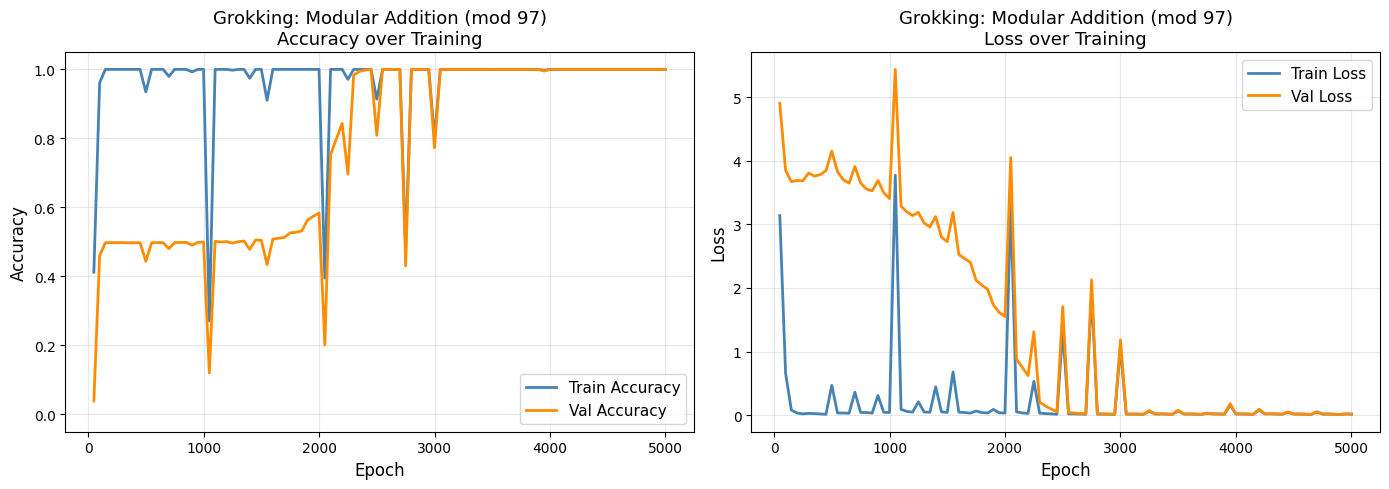

Plot saved as grokking_baseline.png


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(log_steps, train_accs, label='Train Accuracy', color='steelblue', linewidth=2)
ax1.plot(log_steps, val_accs,   label='Val Accuracy',   color='darkorange', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Grokking: Modular Addition (mod 97)\nAccuracy over Training', fontsize=13)
ax1.legend(fontsize=11)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(alpha=0.3)

# Loss plot
ax2.plot(log_steps, train_losses, label='Train Loss', color='steelblue', linewidth=2)
ax2.plot(log_steps, val_losses,   label='Val Loss',   color='darkorange', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Grokking: Modular Addition (mod 97)\nLoss over Training', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('grokking_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as grokking_baseline.png")

In [9]:
grok_epoch = None
for i, (step, vacc) in enumerate(zip(log_steps, val_accs)):
    if vacc >= 0.90:
        grok_epoch = step
        break

if grok_epoch:
    print(f"Grokking detected at epoch {grok_epoch}")
    print(f"  Train accuracy at that point: {train_accs[log_steps.index(grok_epoch)]:.3f}")
    print(f"  Val accuracy at that point:   {val_accs[log_steps.index(grok_epoch)]:.3f}")

    # Find when train accuracy first hit ~100%
    memorize_epoch = None
    for step, tacc in zip(log_steps, train_accs):
        if tacc >= 0.99:
            memorize_epoch = step
            break
    if memorize_epoch:
        print(f"\nMemorization (train acc ≥ 99%) at epoch: {memorize_epoch}")
        print(f"Grokking gap: {grok_epoch - memorize_epoch} epochs after memorization")
else:
    print("Val accuracy didn't reach 90% — try increasing NUM_EPOCHS to 10000")

Grokking detected at epoch 2300
  Train accuracy at that point: 1.000
  Val accuracy at that point:   0.983

Memorization (train acc ≥ 99%) at epoch: 150
Grokking gap: 2150 epochs after memorization


Training weight decay ablation (3 models × 5000 epochs)...


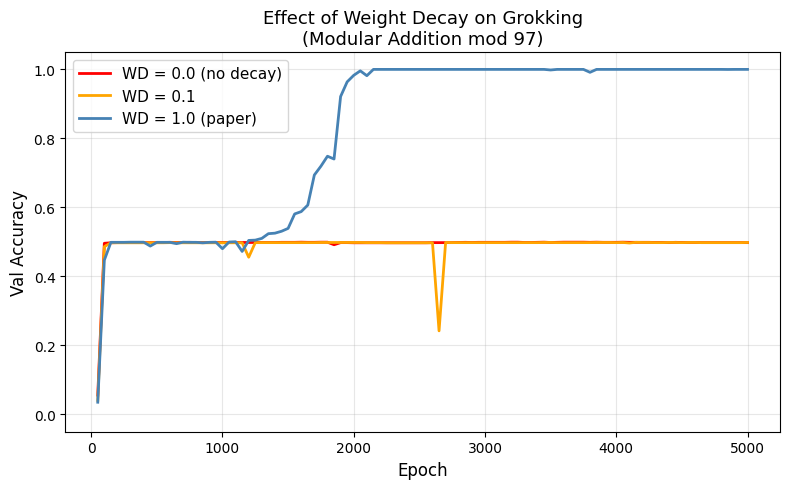

Saved as grokking_weight_decay.png


In [10]:
def train_with_wd(weight_decay, epochs=5000, log_every=50):
    m = TransformerModel(vocab_size=vocab_size).to(device)
    opt = optim.AdamW(m.parameters(), lr=1e-3,
                      weight_decay=weight_decay, betas=(0.9, 0.98))
    v_accs, steps = [], []
    for epoch in range(1, epochs + 1):
        m.train()
        opt.zero_grad()
        loss = criterion(m(x_train_d), y_train_d)
        loss.backward()
        opt.step()
        if epoch % log_every == 0:
            m.eval()
            with torch.no_grad():
                vacc = (m(x_val_d).argmax(-1) == y_val_d).float().mean().item()
            v_accs.append(vacc)
            steps.append(epoch)
    return steps, v_accs

print("Training weight decay ablation (3 models × 5000 epochs)...")
steps0, accs0 = train_with_wd(0.0)
steps1, accs1 = train_with_wd(0.1)
steps2, accs2 = train_with_wd(1.0)

plt.figure(figsize=(8, 5))
plt.plot(steps0, accs0, label='WD = 0.0 (no decay)', color='red',      linewidth=2)
plt.plot(steps1, accs1, label='WD = 0.1',             color='orange',   linewidth=2)
plt.plot(steps2, accs2, label='WD = 1.0 (paper)',     color='steelblue',linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Val Accuracy', fontsize=12)
plt.title('Effect of Weight Decay on Grokking\n(Modular Addition mod 97)', fontsize=13)
plt.legend(fontsize=11)
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('grokking_weight_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as grokking_weight_decay.png")